In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
# from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose

import glob
import os
import csv
import ast

from scipy.stats import chi2_contingency
from math import sqrt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import statsmodels.api as sm

In [2]:
from pathlib import Path

DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)


In [3]:
# Souqeth 

In [4]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Reading Temp & Precip (6km) 

In [5]:
temp_all = pd.read_csv(DATA_DIR / 'processed_weather_data/temp_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
temp_all['time'] = pd.to_datetime(temp_all['time'])

precip_all = pd.read_csv(DATA_DIR / 'processed_weather_data/precip_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
precip_all['time'] = pd.to_datetime(precip_all['time'])

### Wind (6km) 

In [6]:
hourly_wind_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_wind_avg_6km.csv').drop(columns=['Unnamed: 0'])
hourly_wind_df['Timestamp'] = pd.to_datetime(hourly_wind_df['Timestamp'])
hourly_wind_df = hourly_wind_df.rename(columns = {'Timestamp':'time'})
hourly_wind_df['Date'] = hourly_wind_df['time'].dt.date

### Lightning (6km) 

In [7]:
hourly_lightning_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_lightning_avg_6km_buffer_aligned.csv').drop(columns=['Unnamed: 0'])
hourly_lightning_df['Timestamp'] = pd.to_datetime(hourly_lightning_df['Timestamp'])
hourly_lightning_df = hourly_lightning_df.rename(columns = {'Timestamp':'time'})
hourly_lightning_df['Date'] = hourly_lightning_df['time'].dt.date

### Extreme Definitions 

### Temp 

In [8]:
# temp_all['Temp'].quantile(0.95)

In [9]:
temp_all['Date'] = temp_all['time'].dt.floor('D')

# Hot hour flag
temp_all['Hot_Hour'] = temp_all['Temp'] > 32

# Group by EA and Date, and count Hot_Hour sum
daily_hot_hours = (
    temp_all.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Hot_Hour': 'sum'})
)

daily_hot_hours = daily_hot_hours.rename(columns={'Hot_Hour': 'Num_Hot_Hours'})

### Precip 

In [10]:
precip_all['Date'] = precip_all['time'].dt.floor('D')  

# Group by EA and Date, sum Precip
daily_precip = (
    precip_all.groupby(['ea_code9ch', 'Date'], as_index=False)
      .agg({'Precip': 'sum'})
)

### Wind 

In [11]:
# Windy hour flag
hourly_wind_df['Windy_Hour'] = hourly_wind_df['Wind Gusts (m/s)'] > 5.93

# Group by EA and Date, and count Windy_Hour sum
daily_windy_hours = (
    hourly_wind_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Windy_Hour': 'sum'})
)

daily_windy_hours = daily_windy_hours.rename(columns={'Windy_Hour': 'Num_Windy_Hours'})

### Lightning 

In [12]:
daily_lightning_per_ea = hourly_lightning_df.groupby(['ea_code9ch', 'Date'])['Lightning Events'].sum().reset_index()

## Percentiles 

In [13]:
### 90th pct 
hot_hrs_90_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.90)
temp_90_thresh = temp_all['Temp'].quantile(0.90)

precip_90_thresh = daily_precip['Precip'].quantile(0.90)
lightning_90_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.90)

windy_hrs_90_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.90)
wind_90_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.90)


### 95th pct 

hot_hrs_95_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.95)
temp_95_thresh = temp_all['Temp'].quantile(0.95)
precip_95_thresh = daily_precip['Precip'].quantile(0.95)
lightning_95_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.95)
windy_hrs_95_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.95)
wind_95_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.95)

### 99th pct 
hot_hrs_99_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.99)
temp_99_thresh = temp_all['Temp'].quantile(0.99)
precip_99_thresh = daily_precip['Precip'].quantile(0.99)
lightning_99_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.99)
windy_hrs_99_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.99)
wind_99_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.99)

#### Dictionary for percentiles 

In [14]:
# Percentile Threshold dictionaries 
temp_thresh_dict = {
    '90': temp_90_thresh.round(2),
    '95': temp_95_thresh.round(2),
    '99': temp_99_thresh.round(2)
}

hot_hrs_thresh_dict = {
    '90': hot_hrs_90_thresh.round(2),
    '95': hot_hrs_95_thresh.round(2),
    '99': hot_hrs_99_thresh.round(2)
}

precip_thresh_dict = {
    '90': precip_90_thresh.round(2),
    '95': precip_95_thresh.round(2),
    '99': precip_99_thresh.round(2)
}

wind_thresh_dict = {
    '90': wind_90_thresh.round(2),
    '95': wind_95_thresh.round(2),
    '99': wind_99_thresh.round(2)
}

windy_hrs_thresh_dict = {
    '90': windy_hrs_90_thresh.round(2),
    '95': windy_hrs_95_thresh.round(2),
    '99': windy_hrs_99_thresh.round(2)
}

lightning_thresh_dict = {
    '90': 1,   # at least 1 lightning strike 
    '95': lightning_95_thresh.round(2),
    '99': lightning_99_thresh.round(2)
}

### Read EAs and CESI level 

In [15]:
eas_n_cesi_level = pd.read_csv(DATA_DIR / 'miscellaneous/eas_cesi_level_214_eas.csv')

### EA Names mapped  

In [16]:
ea_names_mapped = pd.read_csv(DATA_DIR / 'miscellaneous/ea_names_mapped.csv')

ea_names_mapped = ea_names_mapped[['ea_code9ch', 'LOC_NAME', 'BASE_NAM', 'geometry']]

### EAs n Sites  (6km) 

In [17]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

In [18]:
# merged_eas_sites['ea_code9ch'].nunique()

In [19]:
filtered_eas_sites_copy = merged_eas_sites

In [20]:
# EA -> 30200014, 30500020 

In [21]:
def prepare_hourly_weather_df_TPLW(
    ea_row, 
    temp_df, 
    precip_df, 
    lightning_df, 
    wind_df, 
):
    ea = ea_row['ea_code9ch']
    site_list = [int(s) for s in ea_row['Intersecting_Sites']]
    all_sites_dfs = []

    for site_id in site_list:
        # --- Temperature ---
        temp_filt = (
            temp_df[temp_df['ea_code9ch'] == ea]
            .drop(columns=['geometry'], errors='ignore')
            .copy()
        )
        if 'Hot_Hour' in temp_filt.columns:
            temp_filt = temp_filt.drop(columns=['Hot_Hour'])
        temp_filt['time'] = pd.to_datetime(temp_filt['time'])

        # --- Precipitation ---
        precip_filt = (
            precip_df[precip_df['ea_code9ch'] == ea]
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Precip']]
        )
        precip_filt['time'] = pd.to_datetime(precip_filt['time'])

        # Merge temp + precip
        merged = temp_filt.merge(precip_filt, on='time', how='outer')

        # --- Lightning ---
        lightning_filt = (
            lightning_df[lightning_df['ea_code9ch'] == ea]
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Lightning Events']]
        )
        merged = merged.merge(lightning_filt, on='time', how='outer')
        merged['Lightning Events'] = merged['Lightning Events'].fillna(0)

        # --- Wind ---
        wind_filt = (
            wind_df[wind_df['ea_code9ch'] == ea]
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Wind Gusts (m/s)']]
        )
        merged = merged.merge(wind_filt, on='time', how='inner')

        # Add site_id
        merged['site_id'] = site_id

        all_sites_dfs.append(merged)

    # Concatenate all sites
    df_all = pd.concat(all_sites_dfs, ignore_index=True)

    # Aggregate by timestamp 
    agg_dict = {
        'Temp': 'mean',  # average across sites
        'Precip': 'mean',
        'Lightning Events': 'mean',
        'Wind Gusts (m/s)': 'mean',
        'site_id': lambda x: ','.join(map(str, x))  # list all contributing sites
    }

    df_agg = df_all.groupby('time', as_index=False).agg(agg_dict)

    # Add EA code
    df_agg['ea_code9ch'] = ea

    # Optional: reorder columns
    df_agg = df_agg[
        ['time', 'ea_code9ch', 'site_id', 'Temp', 'Precip', 
         'Lightning Events', 'Wind Gusts (m/s)']
    ]

    return df_agg

## Remove sites with > `10%` missing data & less than 24 months 

In [22]:
sites_to_omit = pd.read_csv(DATA_DIR / 'miscellaneous/complete_site_removal_df.csv')['site_id'].to_list()

### Resample hourly weather data -> Daily 

In [23]:
filtered_eas_sites_copy_r1 = merged_eas_sites.copy()

In [24]:
# Main loop
results = []

for _, row in filtered_eas_sites_copy_r1.iterrows():
    merged_hourly = prepare_hourly_weather_df_TPLW(
        row, 
        temp_all, 
        precip_all, 
        hourly_lightning_df, 
        hourly_wind_df, 
    )
    if merged_hourly is not None:
        results.append(merged_hourly)

merged_hourly_data_global = pd.concat(results, ignore_index=True)

In [25]:
merged_hourly_data_global = merged_hourly_data_global.loc[
    ~merged_hourly_data_global['site_id'].isin(sites_to_omit)
]

In [26]:
### Filter 214 EAs 

tplw_eas = pd.read_csv(DATA_DIR / 'miscellaneous/unique_ea_codes_TPLW.csv')

list_EAs = tplw_eas['ea_code9ch'].unique().tolist()

hourly_global_test = merged_hourly_data_global[merged_hourly_data_global['ea_code9ch'].isin(list_EAs)].reset_index(drop=True)

In [27]:
hourly_global_test['ea_code9ch'].nunique()

214

In [28]:
# 1. Convert to string (just in case)
hourly_global_test['site_id'] = hourly_global_test['site_id'].astype(str)

# 2. Split into list
hourly_global_test['site_id'] = hourly_global_test['site_id'].str.split(',')

# 3. Explode into separate rows
hourly_global_test = hourly_global_test.explode('site_id')

# 4. Clean up (remove spaces + convert to int)
hourly_global_test['site_id'] = hourly_global_test['site_id'].str.strip().astype(int)

### Filter Weather data 

In [29]:
hourly_temperature = hourly_global_test.drop(columns = ['Precip', 'Lightning Events', 'Wind Gusts (m/s)']).reset_index(drop=True)

# *** Regression Analysis 

### read hourly voltage, EA <-> CESI Mapping & Merge  

### read for all sensors 

In [30]:
hourly_voltage_22 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_22.csv')
hourly_voltage_23 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_23.csv')

hourly_voltage = pd.concat([hourly_voltage_22, hourly_voltage_23], axis=0, ignore_index=True)
hourly_voltage['time'] = pd.to_datetime(hourly_voltage['time'])

### sensors of interest 

In [31]:
sensor_of_interest_list = pd.read_csv(DATA_DIR / 'miscellaneous/common_sensors_22_23_rev4.csv')['respondent_id'].unique().tolist()

hourly_voltage = hourly_voltage[hourly_voltage['sensor_id'].isin(sensor_of_interest_list)].reset_index(drop=True)

In [32]:
## EA <-> CESI Mapping 
sensor_ea_mapping = pd.read_csv(DATA_DIR / 'miscellaneous/sensor_ea_mapping_rev1.csv').drop(columns=['Unnamed: 0'])

## Merge 
hourly_voltage = hourly_voltage.merge(sensor_ea_mapping, on = ['sensor_id', 'site_id'], how = 'left')

### Combine weather & voltage 

In [33]:
hourly_volt_n_temp = hourly_voltage.merge(hourly_temperature, on = ['time', 'site_id', 'ea_code9ch'], how = 'left')
hourly_volt_n_temp = hourly_volt_n_temp[['time', 'ea_code9ch', 'site_id', 'sensor_id', 'voltage', 'Temp', 'cesi_level']]
hourly_volt_n_temp['Temp'] = hourly_volt_n_temp['Temp'].round(3)

### Remove NaNs 

In [34]:
hourly_volt_n_temp = hourly_volt_n_temp.dropna().reset_index(drop=True)

### flag undervolts and extreme temps 

In [35]:
def add_flags(df, volt_thresh, temp_thresh):
    df = df.copy()

    # Undervoltage flag
    df['undervolt'] = (df['voltage'] < volt_thresh).astype(int)

    # Extreme temperature flag
    df['extreme_temp'] = (df['Temp'] >= temp_thresh).astype(int)

    return df

### specify hour undervolt thresh 

<div style="background-color:#fff3cd; color:#664d03; padding:12px; border-left:5px solid #ffec99; border-radius:6px;">

### *** using 207 for simplicity 

</div>

In [36]:
hr_undervolt_thresh = 207 
# hr_undervolt_thresh = 200 

### add `undervolt` & `extreme_temp` flags 

<div style="background-color:#fff3cd; color:#664d03; padding:12px; border-left:5px solid #ffec99; border-radius:6px;">

### *** using the 95th pct which is close to the WHO thermal comfort thresh 

</div>

In [37]:
hourly_volt_n_temp_flagged = add_flags(
        hourly_volt_n_temp, 
        volt_thresh = hr_undervolt_thresh,        ## undervolt hour thresh 
        temp_thresh = temp_thresh_dict['95'],     ## 95th percentile temp 
)

# re-order 
hourly_volt_n_temp_flagged = hourly_volt_n_temp_flagged[['time', 'ea_code9ch', 'site_id', 'sensor_id', 
                                                         'voltage', 'undervolt', 
                                                         'Temp', 'extreme_temp', 
                                                        'cesi_level']]

# A. Pooled Results (*all sensors together*)

### Same hour interaction (undervolt & high temp) 

In [38]:
def run_pooled_undervolt_logit(
    df,
    outcome_col='undervolt',
    exposure_col='extreme_temp',
    time_col='time',
    cluster_col='sensor_id',
    add_month_fe=True,
    add_hour_fe=True,
    use_cluster=True,
    disp=0
):

    df = df.copy()

    # Ensure datetime
    df[time_col] = pd.to_datetime(df[time_col])

    # Time features
    df['month'] = df[time_col].dt.month
    df['hour'] = df[time_col].dt.hour

    # Ensure binary
    df[outcome_col] = df[outcome_col].astype(int)
    df[exposure_col] = df[exposure_col].astype(int)

    # Outcome
    y = df[outcome_col]

    # Predictors
    X = df[[exposure_col]].copy()

    if add_month_fe:
        X['month'] = df['month']

    if add_hour_fe:
        X['hour'] = df['hour']

    # Fixed effects
    fe_cols = []
    if add_month_fe:
        fe_cols.append('month')

    if add_hour_fe:
        fe_cols.append('hour')

    if fe_cols:
        X = pd.get_dummies(X, columns=fe_cols, drop_first=True)

    X = X.astype(float)
    X = sm.add_constant(X)

    # Fit model
    if use_cluster:
        model = sm.Logit(y, X).fit(
            cov_type='cluster',
            cov_kwds={'groups': df[cluster_col]},
            disp=disp
        )
    else:
        model = sm.Logit(y, X).fit(disp=disp)

    return model

## *** 1) Define Heat Spells 

### Extreme Temp in X out of Y hours --> not sure I'll use this 

In [39]:
import pandas as pd

def add_heat_spell_flag(
    df,
    time_col='time',
    sensor_col='sensor_id',
    exposure_col='extreme_temp',
    window_hours=24,
    threshold=4,
    include_current=True
):
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col])
    df[exposure_col] = df[exposure_col].astype(int)

    # Sort for proper rolling
    df = df.sort_values([sensor_col, time_col]).reset_index(drop=True)

    x = df.groupby(sensor_col)[exposure_col]

    # Rolling count of extreme temp hours
    if include_current:
        rolling_sum = x.transform(
            lambda s: s.rolling(window=window_hours, min_periods=1).sum()
        )
        col_name = f'heat_spell_{threshold}_of_{window_hours}hr_incl_current'
    else:
        rolling_sum = x.transform(
            lambda s: s.shift(1).rolling(window=window_hours, min_periods=1).sum()
        )
        col_name = f'heat_spell_{threshold}_of_prev_{window_hours}hr'

    # Define heat spell
    df[col_name] = (rolling_sum >= threshold).astype(int)

    # Clean sort
    sort_cols = [c for c in ['site_id', sensor_col, time_col] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True)

    return df

### 4 out of 6 hrs 

In [40]:
# df_heat = add_heat_spell_flag(
#     hourly_volt_n_temp_flagged,
#     exposure_col='extreme_temp',
#     window_hours = 6,
#     threshold = 2,
#     include_current = True
# )

## *** Undervoltages unlike outages (daily) are at the hourly resolution 

### so to define a heat spell, we look at what is extreme for diff hour windows (4, 6, 8, 12, 24, 48) 

### use `discrete blocks` 

### calculate the 95th percentile of number of high temp hours within the block 

In [41]:
import pandas as pd
import numpy as np

def define_heat_spell_from_time_blocks(
    df,
    temp_col='Temp',
    time_col='time',
    ea_col='ea_code9ch',
    sensor_col='sensor_id',
    threshold_temp=32.16,
    block_hours=4,
    percentile=95,
    block_origin='start_day'
):
    """
    Defines heat spell flags using discrete, non-overlapping time blocks.

    Steps:
    1. Aggregates temperature to one value per EA-hour.
    2. Flags hours where temperature >= threshold_temp.
    3. Assigns each hour to a fixed time block.
    4. Counts extreme-temp hours within each EA-block.
    5. Finds the percentile threshold of block counts.
    6. Flags heat spell blocks where count >= percentile threshold.
    """

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])

    # --------------------------------------------------
    # 1. Collapse to one temperature value per EA-hour
    # --------------------------------------------------
    ea_hourly = (
        df.groupby([ea_col, time_col], as_index=False)
          .agg(
              Temp_mean=(temp_col, 'mean'),
              n_sensors=(sensor_col, 'nunique')
          )
    )

    # --------------------------------------------------
    # 2. Flag extreme temperature hours
    # --------------------------------------------------
    ea_hourly['extreme_temp_hour'] = (
        ea_hourly['Temp_mean'] >= threshold_temp
    ).astype(int)

    # --------------------------------------------------
    # 3. Assign discrete non-overlapping time blocks
    # --------------------------------------------------
    freq = f'{block_hours}h'

    ea_hourly['time_block_start'] = (
        ea_hourly[time_col]
        .dt.floor(freq)
    )

    ea_hourly['time_block_end'] = (
        ea_hourly['time_block_start']
        + pd.to_timedelta(block_hours, unit='h')
    )

    # --------------------------------------------------
    # 4. Count extreme-temp hours within each EA-block
    # --------------------------------------------------
    block_df = (
        ea_hourly
        .groupby([ea_col, 'time_block_start', 'time_block_end'], as_index=False)
        .agg(
            extreme_hours_in_block=('extreme_temp_hour', 'sum'),
            total_hours_in_block=('extreme_temp_hour', 'count'),
            Temp_mean_block=('Temp_mean', 'mean'),
            Temp_max_block=('Temp_mean', 'max'),
            n_sensors_mean=('n_sensors', 'mean')
        )
    )

    # --------------------------------------------------
    # 5. Find percentile threshold
    # --------------------------------------------------
    heat_spell_threshold = np.nanpercentile(
        block_df['extreme_hours_in_block'],
        percentile
    )

    # Since block counts are discrete, round up
    heat_spell_threshold = int(np.ceil(heat_spell_threshold))

    # --------------------------------------------------
    # 6. Flag heat spell blocks
    # --------------------------------------------------
    block_df[f'heat_spell_{block_hours}hr'] = (
        block_df['extreme_hours_in_block'] >= heat_spell_threshold
    ).astype(int)

    # --------------------------------------------------
    # 7. Keep useful metadata
    # --------------------------------------------------
    block_df.attrs['threshold_temp'] = threshold_temp
    block_df.attrs['block_hours'] = block_hours
    block_df.attrs['percentile'] = percentile
    block_df.attrs['heat_spell_threshold_hours'] = heat_spell_threshold

    print(f"Extreme temp threshold: Temp >= {threshold_temp}°C")
    print(f"Discrete block size: {block_hours} hours")
    print(f"{percentile}th percentile block-count threshold: {heat_spell_threshold} extreme hours")
    print(
        f"Heat spell definition: at least {heat_spell_threshold} "
        f"extreme-temp hours within a discrete {block_hours}-hour block"
    )

    return block_df

In [42]:
heat_spell_block_df = define_heat_spell_from_time_blocks(
    hourly_volt_n_temp,
    threshold_temp = temp_thresh_dict['95'],
    block_hours = 48,
    percentile = 95
)

Extreme temp threshold: Temp >= 32.16°C
Discrete block size: 48 hours
95th percentile block-count threshold: 9 extreme hours
Heat spell definition: at least 9 extreme-temp hours within a discrete 48-hour block


In [43]:
heat_spell_block_df

,ea_code9ch,time_block_start,time_block_end,extreme_hours_in_block,total_hours_in_block,Temp_mean_block,Temp_max_block,n_sensors_mean,heat_spell_48hr
0,30200002,2021-12-31,2022-01-02,0,24,28.566958,32.109,2.0000,0
1,30200002,2022-01-02,2022-01-04,3,48,28.135708,33.167,2.0000,0
2,30200002,2022-01-04,2022-01-06,0,48,28.363646,32.108,2.0000,0
3,30200002,2022-01-06,2022-01-08,4,48,29.103125,32.649,2.0000,0
4,30200002,2022-01-08,2022-01-10,9,48,29.474979,34.046,2.0000,1
...,...,...,...,...,...,...,...,...,...
71953,31300407,2023-12-23,2023-12-25,12,48,29.082750,34.582,3.0000,1
71954,31300407,2023-12-25,2023-12-27,11,48,29.265354,35.277,3.0000,1
71955,31300407,2023-12-27,2023-12-29,9,48,29.079146,33.896,3.0000,1
71956,31300407,2023-12-29,2023-12-31,9,48,28.997938,33.457,2.9375,1


### map heat spells back to hourly volt & temp df 

### all hours with a heat spell `flagged` as 1 

In [44]:
def map_heat_spell_blocks_to_hourly(
    hourly_df,
    heat_spell_block_df,
    time_col='time',
    ea_col='ea_code9ch',
    sensor_col='sensor_id',
    block_start_col='time_block_start',
    block_end_col='time_block_end',
    heat_spell_col=None
):
    """
    Maps EA-level heat spell block flags back onto sensor-hour rows.
    Automatically detects the heat spell column if heat_spell_col is not passed.
    """

    hourly_df = hourly_df.copy()
    block_df = heat_spell_block_df.copy()

    hourly_df[time_col] = pd.to_datetime(hourly_df[time_col])
    block_df[block_start_col] = pd.to_datetime(block_df[block_start_col])
    block_df[block_end_col] = pd.to_datetime(block_df[block_end_col])

    # --------------------------------------------------
    # Automatically detect heat spell column
    # --------------------------------------------------
    if heat_spell_col is None:
        heat_spell_cols = [
            col for col in block_df.columns
            if col.startswith('heat_spell')
        ]

        if len(heat_spell_cols) == 0:
            raise ValueError("No heat spell column found. Expected a column starting with 'heat_spell'.")

        if len(heat_spell_cols) > 1:
            raise ValueError(
                f"Multiple heat spell columns found: {heat_spell_cols}. "
                "Please pass heat_spell_col explicitly."
            )

        heat_spell_col = heat_spell_cols[0]

    # Keep only needed block-level columns
    block_cols = [
        ea_col,
        block_start_col,
        block_end_col,
        heat_spell_col
    ]

    block_df = block_df[block_cols]

    # Infer block size from block start/end
    block_hours = int(
        (block_df[block_end_col].iloc[0] - block_df[block_start_col].iloc[0])
        / pd.Timedelta(hours=1)
    )

    # Assign each hourly row to its matching block start
    hourly_df[block_start_col] = hourly_df[time_col].dt.floor(f'{block_hours}h')

    # Merge block-level heat spell flag onto hourly sensor data
    merged = hourly_df.merge(
        block_df.drop(columns=[block_end_col]),
        on=[ea_col, block_start_col],
        how='left'
    )

    # Fill missing heat spell flags with 0
    merged[heat_spell_col] = merged[heat_spell_col].fillna(0).astype(int)

    # Sort final output
    merged = merged.sort_values(
        [ea_col, sensor_col, time_col]
    ).reset_index(drop=True)

    return merged

In [45]:
hourly_volt_n_temp_heat_spell = map_heat_spell_blocks_to_hourly(
    hourly_volt_n_temp_flagged,
    heat_spell_block_df,
)

In [46]:
hourly_volt_n_temp_heat_spell

,time,ea_code9ch,site_id,sensor_id,voltage,undervolt,Temp,extreme_temp,cesi_level,time_block_start,heat_spell_48hr
0,2022-01-01 00:00:00,30200002,456,5d246142,227.44,0,26.076,0,Low,2021-12-31,0
1,2022-01-01 01:00:00,30200002,456,5d246142,230.44,0,25.957,0,Low,2021-12-31,0
2,2022-01-01 02:00:00,30200002,456,5d246142,227.16,0,25.826,0,Low,2021-12-31,0
3,2022-01-01 03:00:00,30200002,456,5d246142,229.37,0,25.649,0,Low,2021-12-31,0
4,2022-01-01 04:00:00,30200002,456,5d246142,232.13,0,25.420,0,Low,2021-12-31,0
...,...,...,...,...,...,...,...,...,...,...,...
6135644,2023-12-31 19:00:00,31300407,445,f77bdec3,228.33,0,28.473,0,Low,2023-12-31,0
6135645,2023-12-31 20:00:00,31300407,445,f77bdec3,229.46,0,28.180,0,Low,2023-12-31,0
6135646,2023-12-31 21:00:00,31300407,445,f77bdec3,235.57,0,27.907,0,Low,2023-12-31,0
6135647,2023-12-31 22:00:00,31300407,445,f77bdec3,238.59,0,27.678,0,Low,2023-12-31,0


### then I can do undervoltage (whether 1 hour or consecutive) <--> heat spell 

## *** 2) Define Sustained Undervoltages 

In [47]:
def add_consecutive_undervolt_flag(
    df,
    time_col='time',
    sensor_col='sensor_id',
    undervolt_col='undervolt',
    min_hours=2
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])

    # Sort so consecutive logic works
    df = df.sort_values([sensor_col, time_col])

    # New event starts when undervolt status changes
    df['event_group'] = (
        df.groupby(sensor_col)[undervolt_col]
          .transform(lambda x: x.ne(x.shift()).cumsum())
    )

    # Count consecutive rows within each undervolt/non-undervolt spell
    df['spell_length'] = (
        df.groupby([sensor_col, 'event_group'])[undervolt_col]
          .transform('size')
    )

    # Flag only undervolt rows that belong to spells lasting >= min_hours
    df[f'undervolt_{min_hours}hr_plus'] = (
        (df[undervolt_col] == 1) &
        (df['spell_length'] >= min_hours)
    ).astype(int)

    # Drop helper columns
    df = df.drop(columns=['event_group', 'spell_length'])

    # 🔥 Sort by site_id (and time for sanity), then reset index
    df = df.sort_values(['site_id', time_col]).reset_index(drop=True)

    return df

### I think i'll stick to the `1 hour` cos different hours within that heat spell can have an undervoltage & you want to capture that 

### Specify the undervoltage duration (1 hour) 

In [48]:
unv_flagged_1hr = add_consecutive_undervolt_flag(
    hourly_volt_n_temp_flagged,
    min_hours = 1
)

## *** 3) Undervoltages & Heat Spell 

### specify the dfs & merge 

In [49]:
df_sustained_undervolt = unv_flagged_1hr.copy()
df_sustained_temp = hourly_volt_n_temp_heat_spell.copy()

In [50]:
# Dynamically detect columns
heat_col = [c for c in df_sustained_temp.columns if 'heat_spell' in c][0]
undervolt_col = [c for c in df_sustained_undervolt.columns if 'undervolt_' in c and 'hr_plus' in c][0]

merge_cols = ['time', 'ea_code9ch', 'site_id', 'sensor_id', 'voltage', 'undervolt', 'Temp', 'extreme_temp', 'cesi_level']

# Merge
hourly_combined_heat_n_temp = df_sustained_undervolt.merge(
    df_sustained_temp[merge_cols + [heat_col]],
    on=merge_cols,
    how='left'
)

hourly_combined_heat_n_temp = hourly_combined_heat_n_temp.sort_values(['site_id', 'sensor_id', 'time']).reset_index(drop=True)

print(f"Using outcome column: {undervolt_col}")
print(f"Using exposure column: {heat_col}")

Using outcome column: undervolt_1hr_plus
Using exposure column: heat_spell_48hr


### combined df having heat spell & specified undervolt duration  

In [51]:
hourly_combined_heat_n_temp.head()

,time,ea_code9ch,site_id,sensor_id,voltage,undervolt,Temp,extreme_temp,cesi_level,undervolt_1hr_plus,heat_spell_48hr
0,2022-01-01 00:00:00,30410207,1,bb3ff846,236.64,0,26.221,0,Low,0,0
1,2022-01-01 01:00:00,30410207,1,bb3ff846,235.38,0,26.100,0,Low,0,0
2,2022-01-01 02:00:00,30410207,1,bb3ff846,235.45,0,25.953,0,Low,0,0
3,2022-01-01 03:00:00,30410207,1,bb3ff846,236.54,0,25.780,0,Low,0,0
4,2022-01-01 04:00:00,30410207,1,bb3ff846,237.72,0,25.564,0,Low,0,0


### Run the model 

In [52]:
# Run model
model = run_pooled_undervolt_logit(
    hourly_combined_heat_n_temp,
    outcome_col = undervolt_col,
    exposure_col = heat_col,
    cluster_col = 'sensor_id'
)

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:     undervolt_1hr_plus   No. Observations:              6135649
Model:                          Logit   Df Residuals:                  6135613
Method:                           MLE   Df Model:                           35
Date:                Fri, 19 Jun 2026   Pseudo R-squ.:                 0.04299
Time:                        00:56:47   Log-Likelihood:            -1.3625e+06
converged:                       True   LL-Null:                   -1.4237e+06
Covariance Type:              cluster   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.8067      0.150    -18.701      0.000      -3.101      -2.513
heat_spell_48hr     0.0872      0.049      1.789      0.074      -0.008       0.183
month_2            -0.0036      

In [53]:
np.exp(0.1190)

np.float64(1.1263699182883529)

### try the diff hours for heat spell as a `sensitivity` check 

# B. Per Sensor Results 

### Run logit per sensor 

In [54]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings

def run_per_sensor_logit_summary(
    df,
    outcome_col,
    exposure_col,
    time_col='time',
    alpha=0.05,
    min_events=10,
    min_exposure=10,
    add_month_fe=True,
    add_hour_fe=True
):
    rows = []

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])

    for (site_id, sensor_id), df_sensor in df.groupby(['site_id', 'sensor_id']):

        row = {
            'site_id': site_id,
            'sensor_id': sensor_id,
            'n_obs': len(df_sensor),
            'n_unv_events': df_sensor[outcome_col].sum(),
            'n_heat_exposure': df_sensor[exposure_col].sum(),
            # 'outcome_col': outcome_col,
            # 'exposure_col': exposure_col
        }

        # -----------------------------
        # Pre-checks
        # -----------------------------
        if df_sensor[outcome_col].nunique() < 2:
            row['status'] = 'no_outcome_variation'
            rows.append(row)
            continue

        if df_sensor[exposure_col].nunique() < 2:
            row['status'] = 'no_exposure_variation'
            rows.append(row)
            continue

        if df_sensor[outcome_col].sum() < min_events:
            row['status'] = 'too_few_events'
            rows.append(row)
            continue

        if df_sensor[exposure_col].sum() < min_exposure:
            row['status'] = 'too_few_exposure'
            rows.append(row)
            continue

        # -----------------------------
        # Fit model safely
        # -----------------------------
        try:
            with warnings.catch_warnings(record=True) as w:
                warnings.simplefilter("always")

                model = run_pooled_undervolt_logit(
                    df_sensor,
                    outcome_col=outcome_col,
                    exposure_col=exposure_col,
                    time_col=time_col,
                    add_month_fe=add_month_fe,
                    add_hour_fe=add_hour_fe,
                    use_cluster=False,
                    disp=0
                )

                warning_text = " | ".join([str(warn.message) for warn in w])

            p_exp = model.pvalues.get(exposure_col, np.nan)
            coef_exp = model.params.get(exposure_col, np.nan)

            converged = model.mle_retvals.get('converged', np.nan)

            # Detect possible separation / instability
            possible_separation = (
                ('separation' in warning_text.lower()) or
                (abs(coef_exp) > 10) or
                (not converged)
            )

            coef_rounded = round(coef_exp, 3) if pd.notna(coef_exp) else np.nan
            or_val = np.exp(coef_exp) if pd.notna(coef_exp) else np.nan
            or_rounded = round(or_val, 3) if pd.notna(or_val) else np.nan
            p_rounded = round(p_exp, 3) if pd.notna(p_exp) else np.nan
            
            row.update({
                'status': 'ok' if converged and not possible_separation else 'unstable',
                'converged': converged,
                'possible_separation': possible_separation,
                'warning_text': warning_text,
                'coef_exposure': coef_rounded,
                'or_exposure': or_rounded,
                'p_exposure': p_rounded,
                'sig_exposure': pd.notna(p_exp) and (p_exp < alpha),
                'pseudo_r2': round(model.prsquared, 3),
                'log_likelihood': round(model.llf, 3),
                'llr_pvalue': round(model.llr_pvalue, 3) if pd.notna(model.llr_pvalue) else np.nan
            })

            # Month and hour effects
            for k in model.params.index:
                if k.startswith('month_') or k.startswith('hour_'):
                    row[k] = model.params[k]
                    row[f'{k}_sig'] = model.pvalues[k] < alpha

        except Exception as e:
            row.update({
                'status': 'failed',
                'converged': False,
                'possible_separation': np.nan,
                'error_message': str(e)
            })

        rows.append(row)

    return pd.DataFrame(rows)

## *** All sensors 

In [55]:
hourly_combined_heat_n_temp_filt = hourly_combined_heat_n_temp.copy()

### run per sensor logic  

### at least 10 hours/observations each of `undervolt` & `heat spell` needed PER SENSOR (to run a valid logit model) 

In [56]:
per_sensor_logit_results = run_per_sensor_logit_summary(
    hourly_combined_heat_n_temp_filt,
    outcome_col = undervolt_col,
    exposure_col = heat_col,
    min_events = 10,
    min_exposure = 10,
    add_month_fe = True,
    add_hour_fe = True
)

per_sensor_logit_results = per_sensor_logit_results.round(3)

In [57]:
per_sensor_logit_results

,site_id,sensor_id,n_obs,n_unv_events,n_heat_exposure,status,converged,possible_separation,warning_text,coef_exposure,...,hour_19_sig,hour_20,hour_20_sig,hour_21,hour_21_sig,hour_22,hour_22_sig,hour_23,hour_23_sig,error_message
0,1,bb3ff846,15847,0,959,no_outcome_variation,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,e2e26a75,16130,0,958,no_outcome_variation,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,e39a61a6,15815,633,935,unstable,False,True,Maximum Likelihood optimization failed to conv...,-1.143,...,False,16.553,False,16.134,False,15.492,False,14.373,False,NaN
3,3,14618a70,16330,116,799,failed,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singular matrix
4,3,377f44ed,11892,748,547,unstable,False,True,Maximum Likelihood optimization failed to conv...,-20.274,...,False,0.120,False,-0.003,False,0.061,False,0.069,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,467,e8fd9673,16839,10,818,failed,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singular matrix
402,469,56bd34f7,16832,9,960,too_few_events,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
403,469,6d123b9d,17408,0,1056,no_outcome_variation,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
404,471,ff71227d,17257,29,808,unstable,False,True,Maximum Likelihood optimization failed to conv...,-9.468,...,False,1.648,False,1.838,False,1.141,False,0.024,False,NaN


| Status | Meaning |
|---|---|
| `ok` | Model fit successfully and results appear reasonably stable. |
| `unstable` | Model fit completed, but there are warning signs such as non-convergence, possible separation, or extremely large coefficients. Results should be interpreted cautiously. |
| `failed` | Model could not be estimated due to an error during fitting (e.g., singular matrix, numerical issues, invalid data). |
| `too_few_events` | The sensor had too few outcome events (e.g., too few undervoltage hours) to reliably estimate a logistic regression. |
| `too_few_exposure` | The sensor had too few exposure hours (e.g., too few heat-spell hours) to reliably estimate the exposure effect. |
| `no_outcome_variation` | The outcome variable never changed for that sensor (e.g., all hours were either undervolt = 0 or all undervolt = 1). Logistic regression requires both classes. |
| `no_exposure_variation` | The exposure variable never changed for that sensor (e.g., all hours were either heat spell = 0 or all = 1). No comparison is possible. |

### keep results only for the sensors with `ok` status and with stat. significance 

In [58]:
converged_sensors = per_sensor_logit_results[(per_sensor_logit_results['status'] == 'ok') & (per_sensor_logit_results['sig_exposure'] == True)].reset_index(drop=True)

converged_sensors = converged_sensors[[
        'site_id', 'sensor_id', 'n_obs', 'n_unv_events', 'n_heat_exposure',
        'status', 'converged', 'coef_exposure', 
        'or_exposure', 'p_exposure', 'sig_exposure'
]]

In [59]:
converged_sensors.head()

,site_id,sensor_id,n_obs,n_unv_events,n_heat_exposure,status,converged,coef_exposure,or_exposure,p_exposure,sig_exposure
0,4,08565208,13206,1821,797,ok,True,0.956,2.602,0.000,True
1,4,6072cd14,17222,4308,980,ok,True,-0.236,0.790,0.011,True
2,4,d0e07e0f,15852,2643,969,ok,True,1.153,3.167,0.000,True
3,4,e13978e1,17028,3112,994,ok,True,0.786,2.194,0.000,True
4,19,11ed5164,17249,5457,798,ok,True,-0.495,0.610,0.000,True


### add the cesi mapping 

In [60]:
sensor_cesi_mapping = sensor_ea_mapping.copy().drop(columns = ['ea_code9ch'])

converged_sensors = converged_sensors.merge(sensor_cesi_mapping, on = ['site_id', 'sensor_id'])

### visualize 

In [61]:
df = converged_sensors.copy()

In [62]:
def plot_or_histogram(
    df,
    bins=20,
    figsize=(8, 5),
    show_kde=True,
    normalize=True,
    show_center=True,
    show_grid_lines=True,
    use_log_scale=False,

    # --- Reference line ---
    ref_line_label=None,
    ref_line_color='red',
    ref_line_style='--',

    # --- Legend ---
    legend_loc='best',
    legend_bbox=None, 
    color = 'grey', 
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.ticker import PercentFormatter
    import numpy as np

    plt.figure(figsize=figsize)

    data = df['or_exposure'].dropna()

    # Optional log transform
    if use_log_scale:
        data = np.log(data)
        if ref_line_label is None:
            ref_line_label = 'No Effect (log OR = 0)'
    else:
        if ref_line_label is None:
            ref_line_label = 'Equal Odds (OR = 1)'

    # --- Histogram ---
    if normalize:
        sns.histplot(
            data,
            bins=bins,
            kde=show_kde,
            stat='percent', 
            color=color
        )
    else:
        sns.histplot(
            data,
            bins=bins,
            kde=show_kde,
            stat='count', 
            color=color
        )

    ax = plt.gca()

    # --- Reference line ---
    ref_val = 0 if use_log_scale else 1

    ax.axvline(
        ref_val,
        linestyle=ref_line_style,
        color=ref_line_color,
        linewidth=2,
        label=ref_line_label
    )

    # --- Mean / Median ---
    if show_center:
        mean_val = data.mean()
        median_val = data.median()

        ax.axvline(
            mean_val,
            color='black',
            linestyle='-',
            linewidth=2,
            label='Mean'
        )

        ax.axvline(
            median_val,
            color='black',
            linestyle='--',
            linewidth=2,
            label='Median'
        )

    # --- Labels ---
    xlabel = "Log Odds Ratio" if use_log_scale else "Relative Undervoltage Likelihood"

    plt.xlabel(
        xlabel,
        fontsize=16,
        labelpad=15,
        fontweight='bold'
    )

    ylabel = "Proportion of Sensors (%)" if normalize else "Count"

    plt.ylabel(
        ylabel,
        fontsize=16,
        labelpad=15,
        fontweight='bold'
    )

    # --- Percent formatting ---
    if normalize:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    # --- Gridlines ---
    if show_grid_lines:
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # --- Ticks ---
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # --- Remove spines ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- Legend ---
    plt.legend(
        frameon=True,
        fontsize=12,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    plt.tight_layout()
    plt.show()

In [63]:
def plot_or_histogram(
    df,
    bins=20,
    figsize=(8, 5),
    show_kde=True,
    normalize=True,
    show_center=True,
    show_grid_lines=True,
    use_log_scale=False,
    # --- Reference line ---
    ref_line_label=None,
    ref_line_color='red',
    ref_line_style='--',
    # --- Legend ---
    legend_loc='best',
    legend_bbox=None,
    color='grey',
    save_path=None,
    dpi=300
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.ticker import PercentFormatter, FuncFormatter
    import numpy as np

    plt.figure(figsize=figsize)
    data = df['or_exposure'].dropna()

    # Optional log transform
    if use_log_scale:
        data = np.log(data)
        if ref_line_label is None:
            ref_line_label = 'No Effect (log OR = 0)'
    else:
        if ref_line_label is None:
            ref_line_label = 'Equal Odds (OR = 1)'

    # --- Histogram ---
    if normalize:
        sns.histplot(
            data,
            bins=bins,
            kde=show_kde,
            stat='percent',
            color=color
        )
    else:
        sns.histplot(
            data,
            bins=bins,
            kde=show_kde,
            stat='count',
            color=color
        )

    ax = plt.gca()

    # --- Reference line ---
    ref_val = 0 if use_log_scale else 1
    ax.axvline(
        ref_val,
        linestyle=ref_line_style,
        color=ref_line_color,
        linewidth=2,
        label=ref_line_label
    )

    # --- Mean / Median ---
    if show_center:
        mean_val = data.mean()
        median_val = data.median()
        ax.axvline(
            mean_val,
            color='black',
            linestyle='-',
            linewidth=2,
            label='Mean'
        )
        ax.axvline(
            median_val,
            color='black',
            linestyle='--',
            linewidth=2,
            label='Median'
        )

    # --- Labels ---
    xlabel = "Log Odds Ratio" if use_log_scale else "Change in Undervoltage Odds During Heat Spells"
    plt.xlabel(
        xlabel,
        fontsize=16,
        labelpad=15,
        fontweight='bold'
    )

    ylabel = "Proportion of Sensors (%)" if normalize else "Count"
    plt.ylabel(
        ylabel,
        fontsize=16,
        labelpad=15,
        fontweight='bold'
    )

    # --- Percent formatting ---
    if normalize:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    # --- X-axis 'X' formatting (only for non-log OR scale) ---
    if not use_log_scale:
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f'{x:g}X')
        )

    # --- Gridlines ---
    if show_grid_lines:
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # --- Ticks ---
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # --- Remove spines ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- Legend ---
    plt.legend(
        frameon=True,
        fontsize=12,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

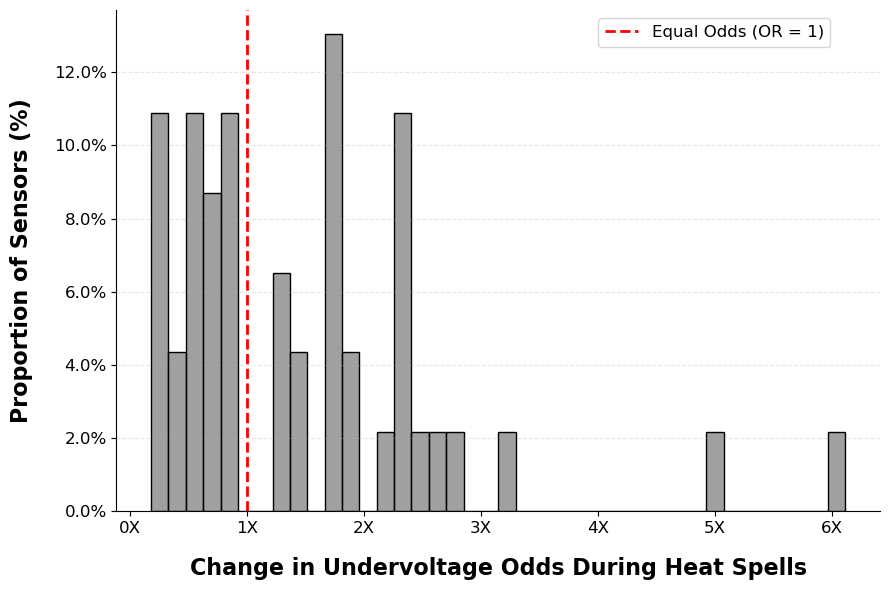

In [64]:
plot_or_histogram(
    df,
    bins=40,
    use_log_scale=False, 
    show_center=False,
    show_kde=False,
    ref_line_label='Equal Odds (OR = 1)',
    legend_loc = 'upper left',
    legend_bbox = (0.62, 1), 
    color = 'grey', 
    figsize=(9, 6),
    save_path=PLOTS_DIR / 'logit_undervolt_hist.png'
)

In [83]:
46/406

0.11330049261083744

In [65]:
df

,site_id,sensor_id,n_obs,n_unv_events,n_heat_exposure,status,converged,coef_exposure,or_exposure,p_exposure,sig_exposure,cesi_level
0,4,08565208,13206,1821,797,ok,True,0.956,2.602,0.000,True,Low
1,4,6072cd14,17222,4308,980,ok,True,-0.236,0.790,0.011,True,Low
2,4,d0e07e0f,15852,2643,969,ok,True,1.153,3.167,0.000,True,Low
3,4,e13978e1,17028,3112,994,ok,True,0.786,2.194,0.000,True,Low
4,19,11ed5164,17249,5457,798,ok,True,-0.495,0.610,0.000,True,Low
5,19,de7753a0,15491,1636,793,ok,True,-0.398,0.672,0.003,True,Low
6,20,69562a09,16416,1178,716,ok,True,-1.471,0.230,0.000,True,Low
7,23,530ad673,15404,4476,761,ok,True,-0.226,0.798,0.041,True,Low
8,24,ec67ce61,16912,4284,897,ok,True,1.810,6.113,0.000,True,Low
9,39,a125ac7f,17256,10614,749,ok,True,-0.233,0.792,0.019,True,Low


In [66]:
df[df['or_exposure']>=1]

,site_id,sensor_id,n_obs,n_unv_events,n_heat_exposure,status,converged,coef_exposure,or_exposure,p_exposure,sig_exposure,cesi_level
0,4,08565208,13206,1821,797,ok,True,0.956,2.602,0.000,True,Low
2,4,d0e07e0f,15852,2643,969,ok,True,1.153,3.167,0.000,True,Low
3,4,e13978e1,17028,3112,994,ok,True,0.786,2.194,0.000,True,Low
8,24,ec67ce61,16912,4284,897,ok,True,1.810,6.113,0.000,True,Low
10,46,32ff3446,16726,6318,1055,ok,True,0.414,1.513,0.000,True,High
11,46,84fae806,6903,2674,433,ok,True,0.516,1.675,0.000,True,High
12,63,50e316ad,17019,1143,930,ok,True,0.542,1.719,0.000,True,Low
13,108,b55263d7,17054,1979,1025,ok,True,0.523,1.687,0.000,True,Low
15,136,10360507,12814,5226,585,ok,True,0.294,1.341,0.004,True,High
20,201,46d58d20,15885,2768,886,ok,True,0.866,2.377,0.000,True,Low


In [87]:
len(df[df['or_exposure']<1])

21

In [88]:
21/46

0.45652173913043476

### disagg by CESI 

In [67]:
def plot_or_histogram_by_cesi(
    df,
    bins=20,
    figsize=(8, 5),
    normalize=True,
    show_center=True,
    show_kde=True,
    show_grid_lines=True,
    fill_value=True,
    use_log_scale=False,
    cesi_label_map=None,

    # --- Reference line ---
    ref_line_label=None,
    ref_line_color='red',
    ref_line_style='--',

    legend_loc='best',
    legend_bbox=None
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.ticker import PercentFormatter
    import matplotlib.lines as mlines
    import numpy as np

    plot_df = df.copy()
    plot_df = plot_df.dropna(subset=['or_exposure', 'cesi_level'])

    if use_log_scale:
        plot_df['or_plot'] = np.log(plot_df['or_exposure'])
        x_col = 'or_plot'
        xlabel = "Log Odds Ratio"
        ref_val = 0
        if ref_line_label is None:
            ref_line_label = 'No Effect (log OR = 0)'
    else:
        plot_df['or_plot'] = plot_df['or_exposure']
        x_col = 'or_plot'
        xlabel = "Relative Undervoltage Likelihood"
        ref_val = 1
        if ref_line_label is None:
            ref_line_label = 'Equal Odds (OR = 1)'

    plt.figure(figsize=figsize)
    ax = plt.gca()

    stat = 'percent' if normalize else 'count'

    levels = plot_df['cesi_level'].dropna().unique()
    palette = dict(zip(levels, sns.color_palette(n_colors=len(levels))))

    sns.histplot(
        data=plot_df,
        x=x_col,
        hue='cesi_level',
        bins=bins,
        stat=stat,
        element='step',
        fill=fill_value,
        alpha=0.2,
        kde=show_kde,
        common_norm=False,
        palette=palette,
        ax=ax
    )

    ref_handle = ax.axvline(
        ref_val,
        linestyle=ref_line_style,
        color=ref_line_color,
        linewidth=2,
        label=ref_line_label
    )

    center_handles = []

    if show_center:
        for level in levels:
            sub = plot_df[plot_df['cesi_level'] == level]
            median_val = sub[x_col].median()

            label = cesi_label_map.get(level, level) if cesi_label_map else level

            ax.axvline(
                median_val,
                linestyle='--',
                linewidth=2,
                color=palette[level],
                alpha=0.9
            )

            center_handles.append(
                mlines.Line2D(
                    [],
                    [],
                    color=palette[level],
                    linestyle='--',
                    linewidth=2,
                    label=f'{label} median'
                )
            )

    ax.set_xlabel(xlabel, fontsize=16, labelpad=15, fontweight='bold')
    ylabel = "Percentage of Sensors (%)" if normalize else "Count"
    ax.set_ylabel(ylabel, fontsize=16, labelpad=15, fontweight='bold')

    if normalize:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    if show_grid_lines:
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    clean_handles = []
    clean_labels = []

    for h, l in zip(handles, labels):
        if l in levels:
            clean_handles.append(h)
            clean_labels.append(l)

    if cesi_label_map is not None:
        clean_labels = [cesi_label_map.get(l, l) for l in clean_labels]

    clean_handles.append(ref_handle)
    clean_labels.append(ref_line_label)

    clean_handles += center_handles
    clean_labels += [h.get_label() for h in center_handles]

    ax.legend(
        handles=clean_handles,
        labels=clean_labels,
        fontsize=14,
        frameon=True,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    ax.tick_params(axis='both', labelsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

In [68]:
def plot_or_histogram_by_cesi(
    df,
    bins=20,
    figsize=(8, 5),
    normalize=True,
    show_center=True,
    show_kde=True,
    show_grid_lines=True,
    fill_value=True,
    use_log_scale=False,
    cesi_label_map=None,
    # --- Reference line ---
    ref_line_label=None,
    ref_line_color='red',
    ref_line_style='--',
    legend_loc='best',
    legend_bbox=None
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.ticker import PercentFormatter
    import matplotlib.lines as mlines
    import numpy as np

    plot_df = df.copy()
    plot_df = plot_df.dropna(subset=['or_exposure', 'cesi_level'])

    if use_log_scale:
        plot_df['or_plot'] = np.log(plot_df['or_exposure'])
        x_col = 'or_plot'
        xlabel = "Log Odds Ratio"
        ref_val = 0
        if ref_line_label is None:
            ref_line_label = 'No Effect (log OR = 0)'
    else:
        plot_df['or_plot'] = plot_df['or_exposure']
        x_col = 'or_plot'
        xlabel = "Relative Undervoltage Likelihood"
        ref_val = 1
        if ref_line_label is None:
            ref_line_label = 'Equal Odds (OR = 1)'

    plt.figure(figsize=figsize)
    ax = plt.gca()

    stat = 'percent' if normalize else 'count'
    levels = plot_df['cesi_level'].dropna().unique()

    # -------------------------
    # CESI color palette
    # -------------------------
    cesi_colors = {
        'Low':    '#6a51a3',
        'Medium': '#238b45',
        'High':   '#8c2d04'
    }

    palette = {
        level: cesi_colors.get(level, fallback)
        for level, fallback in zip(
            levels,
            sns.color_palette(n_colors=len(levels)).as_hex()
        )
    }

    sns.histplot(
        data=plot_df,
        x=x_col,
        hue='cesi_level',
        bins=bins,
        stat=stat,
        element='step',
        fill=fill_value,
        alpha=0.2,
        kde=show_kde,
        common_norm=False,
        palette=palette,
        ax=ax
    )

    ref_handle = ax.axvline(
        ref_val,
        linestyle=ref_line_style,
        color=ref_line_color,
        linewidth=2,
        label=ref_line_label
    )

    center_handles = []
    if show_center:
        for level in levels:
            sub = plot_df[plot_df['cesi_level'] == level]
            median_val = sub[x_col].median()
            label = cesi_label_map.get(level, level) if cesi_label_map else level
            ax.axvline(
                median_val,
                linestyle='--',
                linewidth=2,
                color=palette[level],
                alpha=0.9
            )
            center_handles.append(
                mlines.Line2D(
                    [],
                    [],
                    color=palette[level],
                    linestyle='--',
                    linewidth=2,
                    label=f'{label} median'
                )
            )

    ax.set_xlabel(xlabel, fontsize=16, labelpad=15, fontweight='bold')
    ylabel = "Percentage of Sensors (%)" if normalize else "Count"
    ax.set_ylabel(ylabel, fontsize=16, labelpad=15, fontweight='bold')

    if normalize:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    if show_grid_lines:
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    clean_handles = []
    clean_labels = []
    for h, l in zip(handles, labels):
        if l in levels:
            clean_handles.append(h)
            clean_labels.append(l)

    if cesi_label_map is not None:
        clean_labels = [cesi_label_map.get(l, l) for l in clean_labels]

    clean_handles.append(ref_handle)
    clean_labels.append(ref_line_label)
    clean_handles += center_handles
    clean_labels += [h.get_label() for h in center_handles]

    ax.legend(
        handles=clean_handles,
        labels=clean_labels,
        fontsize=14,
        frameon=True,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    ax.tick_params(axis='both', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

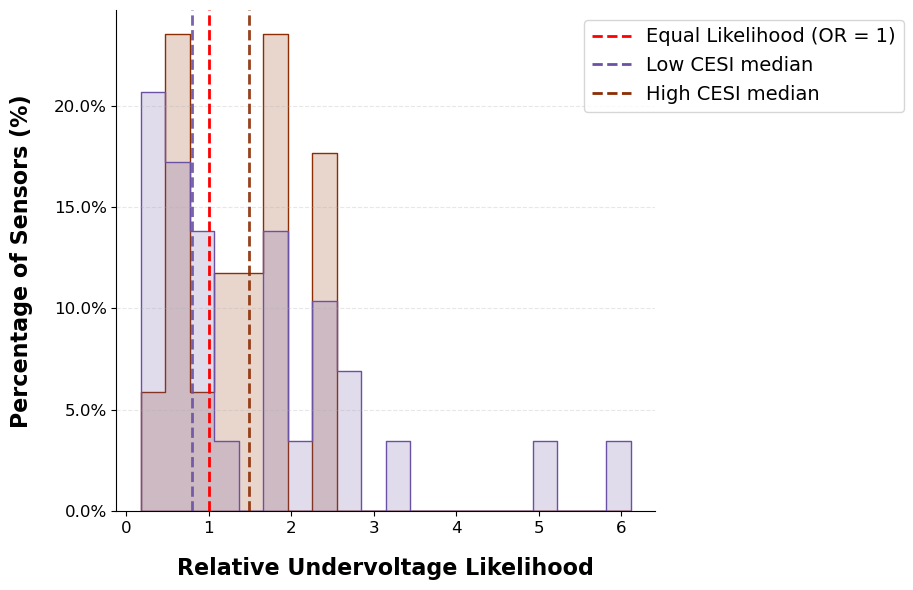

In [69]:
plot_or_histogram_by_cesi(
    df,
    figsize=(9, 6),
    bins=20,
    normalize=True,
    show_kde=False, 
    use_log_scale=False,
    cesi_label_map={
        'Low': 'Low CESI',
        'High': 'High CESI'
    }, 
    ref_line_label='Equal Likelihood (OR = 1)',
    legend_loc = 'upper left',
    legend_bbox = (0.85, 1.0)
)

In [70]:
def plot_or_cdf_by_cesi(
    df,
    figsize=(10, 6),
    show_grid_lines=True,
    cesi_label_map=None,
    legend_loc='best',
    legend_bbox=None,
    use_log_scale=False,

    # --- Reference line ---
    ref_line_label=None,
    ref_line_color='red',
    ref_line_style='--'
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.lines as mlines
    from matplotlib.ticker import PercentFormatter

    plot_df = df.copy()
    plot_df = plot_df.dropna(subset=['or_exposure', 'cesi_level'])

    if use_log_scale:
        plot_df['or_plot'] = np.log(plot_df['or_exposure'])
        xlabel = "Log Odds Ratio"
        ref_val = 0
        if ref_line_label is None:
            ref_line_label = 'No Effect (log OR = 0)'
    else:
        plot_df['or_plot'] = plot_df['or_exposure']
        xlabel = "Relative Undervoltage Likelihood"
        ref_val = 1
        if ref_line_label is None:
            ref_line_label = 'Equal Odds (OR = 1)'

    plt.figure(figsize=figsize)
    ax = plt.gca()

    levels = plot_df['cesi_level'].dropna().unique()
    palette = dict(zip(levels, sns.color_palette(n_colors=len(levels))))

    sns.ecdfplot(
        data=plot_df,
        x='or_plot',
        hue='cesi_level',
        palette=palette,
        ax=ax,
        legend=False
    )

    ref_handle = ax.axvline(
        ref_val,
        linestyle=ref_line_style,
        color=ref_line_color,
        linewidth=2,
        label=ref_line_label
    )

    ax.set_xlabel(xlabel, fontsize=16, labelpad=15, fontweight='bold')
    ax.set_ylabel("Percentage of Sensors", fontsize=16, labelpad=15, fontweight='bold')

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    if show_grid_lines:
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    legend_handles = []

    for level in levels:
        label = cesi_label_map.get(level, level) if cesi_label_map else level
        n = (plot_df['cesi_level'] == level).sum()

        legend_handles.append(
            mlines.Line2D(
                [], [],
                color=palette[level],
                linewidth=2,
                label=f"{label} (n={n})"
            )
        )

    legend_handles.append(ref_handle)

    ax.legend(
        handles=legend_handles,
        fontsize=14,
        frameon=True,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    ax.tick_params(axis='both', labelsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

In [71]:
def plot_or_cdf_by_cesi(
    df,
    figsize=(10, 6),
    show_grid_lines=True,
    cesi_label_map=None,
    legend_loc='best',
    legend_bbox=None,
    use_log_scale=False,
    # --- Reference line ---
    ref_line_label=None,
    ref_line_color='red',
    ref_line_style='--'
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.lines as mlines
    from matplotlib.ticker import PercentFormatter

    plot_df = df.copy()
    plot_df = plot_df.dropna(subset=['or_exposure', 'cesi_level'])

    if use_log_scale:
        plot_df['or_plot'] = np.log(plot_df['or_exposure'])
        xlabel = "Log Odds Ratio"
        ref_val = 0
        if ref_line_label is None:
            ref_line_label = 'No Effect (log OR = 0)'
    else:
        plot_df['or_plot'] = plot_df['or_exposure']
        xlabel = "Relative Undervoltage Likelihood"
        ref_val = 1
        if ref_line_label is None:
            ref_line_label = 'Equal Odds (OR = 1)'

    plt.figure(figsize=figsize)
    ax = plt.gca()

    levels = plot_df['cesi_level'].dropna().unique()

    # -------------------------
    # CESI color palette
    # -------------------------
    cesi_colors = {
        'Low':    '#6a51a3',
        'Medium': '#238b45',
        'High':   '#8c2d04'
    }

    palette = {
        level: cesi_colors.get(level, fallback)
        for level, fallback in zip(
            levels,
            sns.color_palette(n_colors=len(levels)).as_hex()
        )
    }

    sns.ecdfplot(
        data=plot_df,
        x='or_plot',
        hue='cesi_level',
        palette=palette,
        ax=ax,
        legend=False
    )

    ref_handle = ax.axvline(
        ref_val,
        linestyle=ref_line_style,
        color=ref_line_color,
        linewidth=2,
        label=ref_line_label
    )

    ax.set_xlabel(xlabel, fontsize=16, labelpad=15, fontweight='bold')
    ax.set_ylabel("Percentage of Sensors", fontsize=16, labelpad=15, fontweight='bold')
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    if show_grid_lines:
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    legend_handles = []
    for level in levels:
        label = cesi_label_map.get(level, level) if cesi_label_map else level
        n = (plot_df['cesi_level'] == level).sum()
        legend_handles.append(
            mlines.Line2D(
                [], [],
                color=palette[level],
                linewidth=2,
                label=f"{label} (n={n})"
            )
        )
    legend_handles.append(ref_handle)

    ax.legend(
        handles=legend_handles,
        fontsize=14,
        frameon=True,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    ax.tick_params(axis='both', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

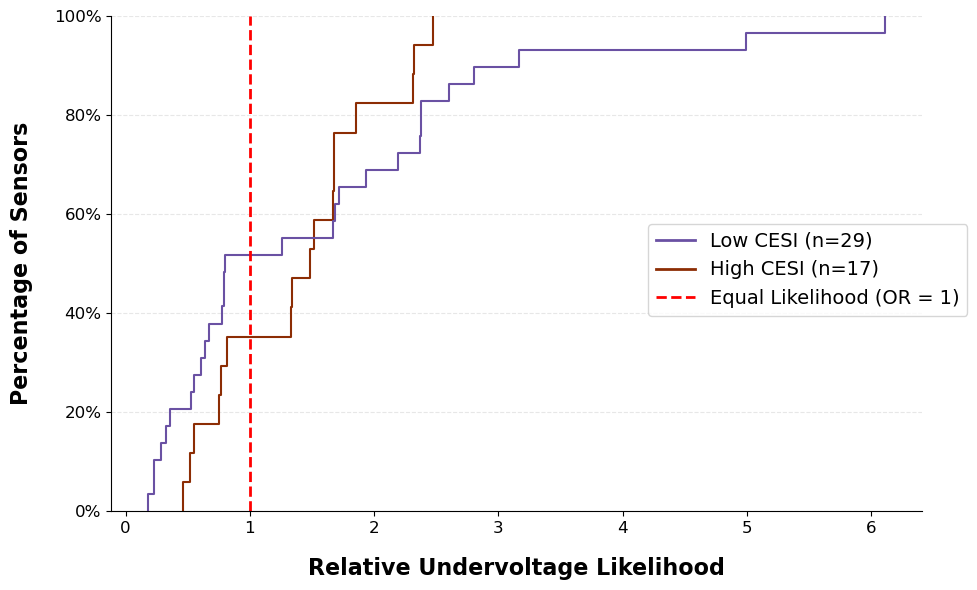

In [72]:
plot_or_cdf_by_cesi(
    df,
    cesi_label_map={
        'Low': 'Low CESI',
        'High': 'High CESI'
    }, 
    ref_line_label='Equal Likelihood (OR = 1)',
    legend_loc = 'upper left',
    legend_bbox = (0.65, 0.6)
)

In [73]:
def plot_or_boxplot_by_cesi(
    df,
    x_col='cesi_level',
    y_col='or_exposure',
    figsize=(8, 6),
    xlabel='CESI Level',
    ylabel='Odds Ratio',
    show_outliers=False,
    show_grid_lines=True,
    palette=None,
    add_jitter=True,
    jitter_alpha=0.5,
    jitter_size=4
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    if palette is None:
        palette = {
            'Low':    '#6a51a3',
            'High':   '#8c2d04'
        }

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # --- Boxplot ---
    sns.boxplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=x_col,
        palette=palette,
        showfliers=show_outliers,
        dodge=False,
        legend=False,
        ax=ax
    )

    # --- Jitter points ---
    if add_jitter:
        sns.stripplot(
            data=df,
            x=x_col,
            y=y_col,
            hue=x_col,
            palette=palette,
            dodge=False,
            jitter=0.25,
            alpha=jitter_alpha,
            size=jitter_size,
            linewidth=0,
            legend=False,
            ax=ax
        )

    # Reference line: OR = 1
    ax.axhline(1, linestyle='--', color='black', linewidth=2)

    # Labels
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', labelpad=15)

    # Gridlines
    if show_grid_lines:
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Tick sizes
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

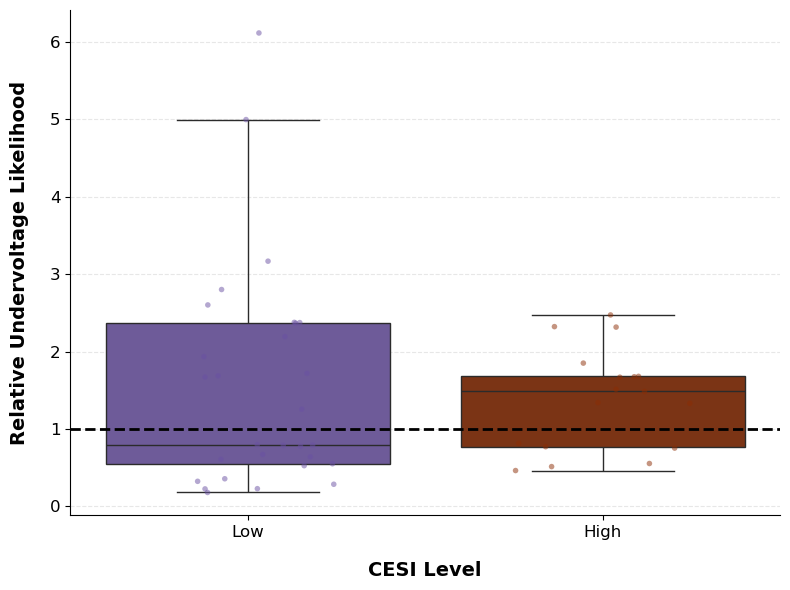

In [74]:
plot_or_boxplot_by_cesi(
    df,
    ylabel='Relative Undervoltage Likelihood',
    show_outliers=False,
    add_jitter=True
)

### check for stat. significant different between the ORs of High & Low CESI sensors 

In [75]:
from scipy.stats import mannwhitneyu

high = df.loc[df['cesi_level'] == 'High', 'coef_exposure']
low  = df.loc[df['cesi_level'] == 'Low', 'coef_exposure']

u_stat, p_val = mannwhitneyu(
    high,
    low,
    alternative='two-sided'
)

print(f"U-statistic: {u_stat:.3f}")
print(f"P-value: {p_val:.4f}")

U-statistic: 256.000
P-value: 0.8377


### for the sensors that converged & have a stat. significant relationship with temperature, NO stat. significant difference exists based on their vulnerability levels 

In [76]:
# converged_sensors 

In [77]:
# len(converged_sensors)

In [78]:
converged_sensors

,site_id,sensor_id,n_obs,n_unv_events,n_heat_exposure,status,converged,coef_exposure,or_exposure,p_exposure,sig_exposure,cesi_level
0,4,08565208,13206,1821,797,ok,True,0.956,2.602,0.000,True,Low
1,4,6072cd14,17222,4308,980,ok,True,-0.236,0.790,0.011,True,Low
2,4,d0e07e0f,15852,2643,969,ok,True,1.153,3.167,0.000,True,Low
3,4,e13978e1,17028,3112,994,ok,True,0.786,2.194,0.000,True,Low
4,19,11ed5164,17249,5457,798,ok,True,-0.495,0.610,0.000,True,Low
5,19,de7753a0,15491,1636,793,ok,True,-0.398,0.672,0.003,True,Low
6,20,69562a09,16416,1178,716,ok,True,-1.471,0.230,0.000,True,Low
7,23,530ad673,15404,4476,761,ok,True,-0.226,0.798,0.041,True,Low
8,24,ec67ce61,16912,4284,897,ok,True,1.810,6.113,0.000,True,Low
9,39,a125ac7f,17256,10614,749,ok,True,-0.233,0.792,0.019,True,Low


In [79]:
# converged_sensors.to_csv('converged_sensors.csv')

In [80]:
## when workflow is complete, try diff undervolt thresholds 

In [81]:
## with a threshold of 207V (avg for the hour); there is a very marginally higher likelihood of undervoltages occurring during heat spells 

## values are highest for a heat spell of 4/6/12/24 hrs (personally, 24 hrs seems a bit long) 

## I assume results would be even less significant at lower thresholds 

In [82]:
## when looking at the results per sensor logic, we consider sensors with at least 10 hours/observations of undervoltages and within the heat spell 

## we also filtered the sensors to only consider those that converged & with stat. significance; ended up with a handful of sensors 

## among these, we found in some (what %?) sensors, it was less likely for them to experience undervoltages during heat spell periods, while for others it was more likely for them to experience undervoltages during heat spell periods 

## for instance, in X% of sensors it was at least 1.5 more likely for an undervoltage to occur during a heat spell...than during during a 'non heat spell' period 